In [93]:
from rdkit import Chem
from rdkit.Chem.Draw import IPythonConsole # 这是支持Jupyter的分子显示模块
from rdkit.Chem import Draw
IPythonConsole.ipython_useSVG=False  # PNG切换SVG开关

In [94]:
def mol_with_atom_index(mol):
    for atom in mol.GetAtoms(): # 遍历分子mol中的所有原子 
        atom.SetAtomMapNum(atom.GetIdx()) # 在原子旁设置索引（映射编号）
    return mol
# <

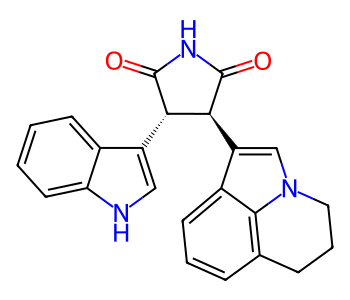

In [95]:
 # 测试分子SMILES画图(无索引)
mol = Chem.MolFromSmiles("C1CC2=C3C(=CC=C2)C(=CN3C1)[C@H]4[C@@H](C(=O)NC4=O)C5=CNC6=CC=CC=C65")
mol

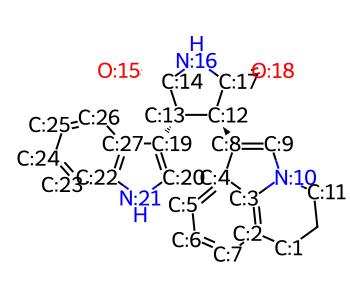

In [96]:
 # 测试分子SMILES画图（有索引）
mol_with_atom_index(mol)

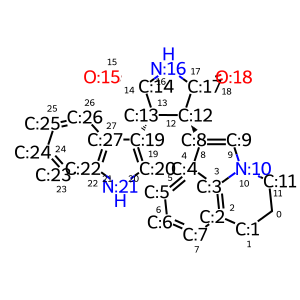

In [97]:
# 使用IPythonConsole在旁边显示索引，而非原子上
IPythonConsole.drawOptions.addAtomIndices = True
IPythonConsole.molSize = 300,300
mol

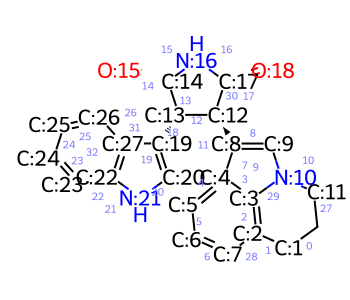

In [98]:
# 显示键的索引
IPythonConsole.drawOptions.addAtomIndices = False
IPythonConsole.drawOptions.addBondIndices = True
IPythonConsole.molSize = 350,300
mol

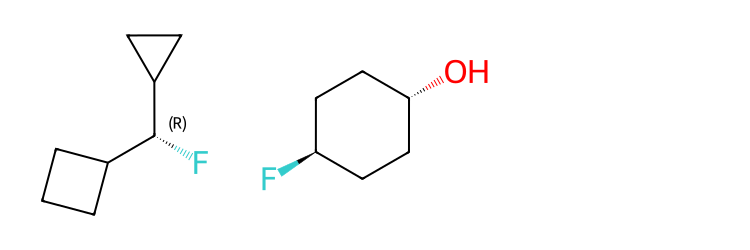

In [99]:
# 显示立体信息
IPythonConsole.drawOptions.addBondIndices = False
IPythonConsole.drawOptions.addStereoAnnotation = True

m1 = Chem.MolFromSmiles('C1CC1[C@H](F)C1CCC1')
m2 = Chem.MolFromSmiles('F[C@H]1CC[C@H](O)CC1')
Draw.MolsToGridImage((m1,m2), subImgSize=(250,250))

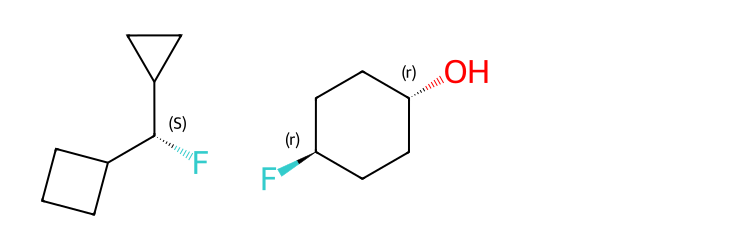

In [100]:
# 新CIP标签分配器的立体信息
from rdkit.Chem import rdCIPLabeler
rdCIPLabeler.AssignCIPLabels(m1)
rdCIPLabeler.AssignCIPLabels(m2)
Draw.MolsToGridImage((m1,m2), subImgSize=(250,250))

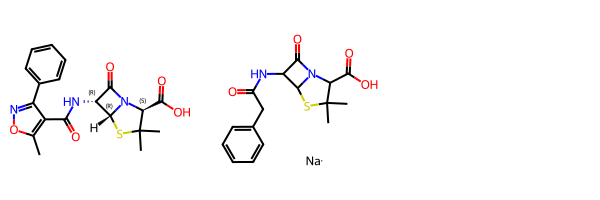

In [101]:
ms = [Chem.MolFromSmiles(x) for x in ('Cc1onc(-c2ccccc2)c1C(=O)N[C@@H]1C(=O)N2[C@@H](C(=O)O)C(C)(C)S[C@H]12','CC1(C)SC2C(NC(=O)Cc3ccccc3)C(=O)N2C1C(=O)O.[Na]')]
Draw.MolsToGridImage(ms) # 另一种并排显示

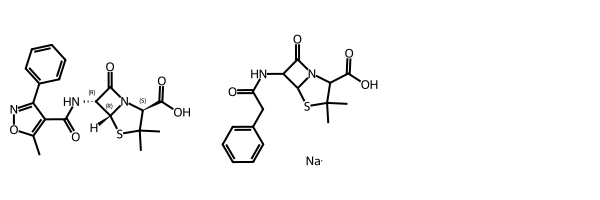

In [102]:
IPythonConsole.drawOptions.useBWAtomPalette() # 纯黑白
Draw.MolsToGridImage(ms) 

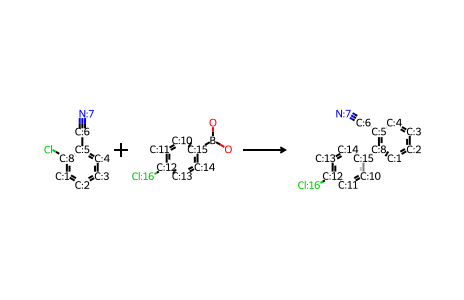

In [103]:
from rdkit.Chem.Draw import rdMolDraw2D
IPythonConsole.drawOptions = rdMolDraw2D.MolDrawOptions() # 此处切回彩色显示

# 绘制一个反应
from rdkit.Chem import rdChemReactions
rxn = rdChemReactions.ReactionFromSmarts("[cH:1]:1:[cH:2]:[cH:3]:[cH:4]:[cH:5](-[C:6]#[N:7]):[c:8]:1-[Cl].\
[cH:10]:1:[cH:11]:[cH:12](-[Cl:16]):[cH:13]:[cH:14]:[cH:15]:1-B(-O)-O>>\
[cH:1]:1:[cH:2]:[cH:3]:[cH:4]:[cH:5](-[C:6]#[N:7]):[c:8]:1-[cH:15]:1[cH:10]:[cH:11]:[cH:12](-[Cl:16]):[cH:13]:[cH:14]:1") # 压力给到SMILES
rxn

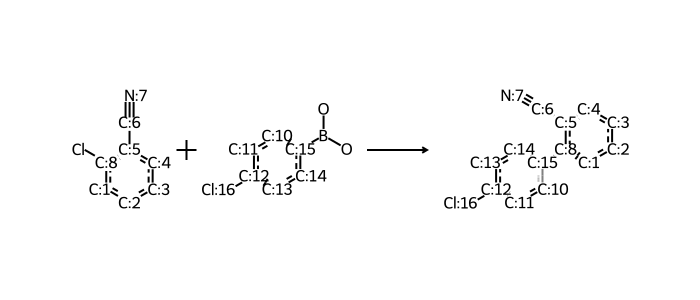

In [104]:
# 显然上一个很拥挤，这里采用Cairo绘图包装成IO的形式
from rdkit.Chem.Draw import rdMolDraw2D
import io
from PIL import Image

drawer = rdMolDraw2D.MolDraw2DCairo(700,300)
drawer.drawOptions().useBWAtomPalette()
drawer.DrawReaction(rxn)
drawer.FinishDrawing()
bio = io.BytesIO(drawer.GetDrawingText())
Image.open(bio)

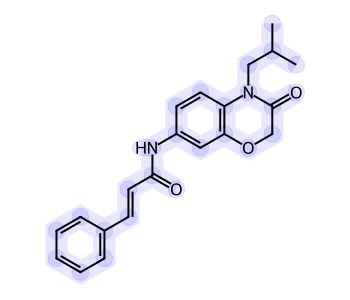

In [109]:
# 整个分子骨架统一高亮（其实没有什么用吧）
mol = Chem.MolFromSmiles('CC(C)CN1C(=O)COC2=C1C=CC(=C2)NC(=O)/C=C/C3=CC=CC=C3')
rgba_color = (0.0, 0.0, 1.0, 0.1) # 透明蓝紫色

atoms = []
for a in mol.GetAtoms():
    atoms.append(a.GetIdx())

bonds = []
for bond in mol.GetBonds():
    aid1 = atoms[bond.GetBeginAtomIdx()]
    aid2 = atoms[bond.GetEndAtomIdx()]
    bonds.append(mol.GetBondBetweenAtoms(aid1,aid2).GetIdx())

drawer = rdMolDraw2D.MolDraw2DCairo(350,300)
drawer.drawOptions().fillHighlights=True
drawer.drawOptions().setHighlightColour((rgba_color))
drawer.drawOptions().highlightBondWidthMultiplier=20
drawer.drawOptions().clearBackground = True
rdMolDraw2D.PrepareAndDrawMolecule(drawer, mol, highlightAtoms=atoms, highlightBonds=bonds)
bio = io.BytesIO(drawer.GetDrawingText())
Image.open(bio)

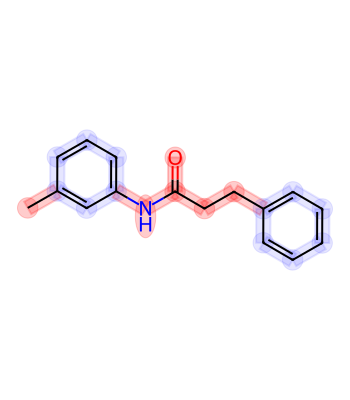

In [110]:
# 分区域不同颜色高亮
from collections import defaultdict

mol = Chem.MolFromSmiles('CC1=CC(=CC=C1)NC(=O)CCC2=CC=CC=C2')
colors = [(0.0, 0.0, 1.0, 0.1), (1.0, 0.0, 0.0, 0.2)]

athighlights = defaultdict(list)
arads = {}
for a in mol.GetAtoms():
    if a.GetIsAromatic(): # 区分是否芳香性
        aid = a.GetIdx()
        athighlights[aid].append(colors[0])
        arads[aid] = 0.3
    else:
        aid = a.GetIdx()
        athighlights[aid].append(colors[1])
        arads[aid] = 0.3

bndhighlights = defaultdict(list)
for bond in mol.GetBonds():
    aid1 = bond.GetBeginAtomIdx()
    aid2 = bond.GetEndAtomIdx()

    if bond.GetIsAromatic():
        bid = mol.GetBondBetweenAtoms(aid1,aid2).GetIdx()
        bndhighlights[bid].append(colors[0])
    else:
        bid = mol.GetBondBetweenAtoms(aid1,aid2).GetIdx()
        bndhighlights[bid].append(colors[1])

d2d = rdMolDraw2D.MolDraw2DCairo(350,400)
d2d.DrawMoleculeWithHighlights(mol,"",dict(athighlights),dict(bndhighlights),arads,{})
d2d.FinishDrawing()
bio = io.BytesIO(d2d.GetDrawingText())
Image.open(bio)

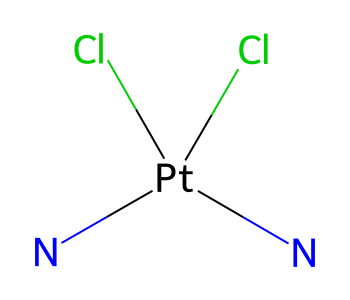

In [111]:
# 去掉不需要现显示的H原子
m = Chem.MolFromSmiles('[Pt](Cl)(Cl)(N)N')

for atom in m.GetAtoms():
    atom.SetProp("atomLabel", atom.GetSymbol())
m

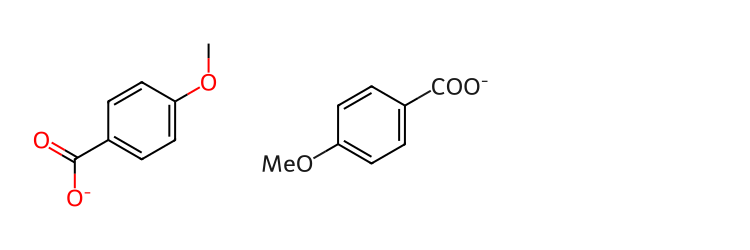

In [112]:
# 显示默认的缩写如Me之类
from rdkit.Chem import rdAbbreviations

m = Chem.MolFromSmiles('COc1ccc(C(=O)[O-])cc1')

abbrevs = rdAbbreviations.GetDefaultAbbreviations()
nm = rdAbbreviations.CondenseMolAbbreviations(m,abbrevs)

Draw.MolsToGridImage((m,nm), subImgSize=(250,250))

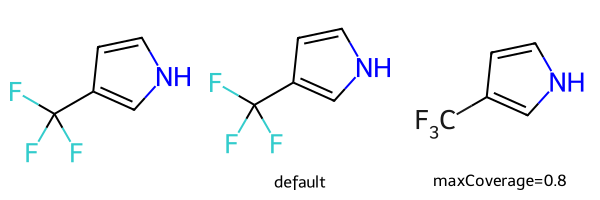

In [113]:
# default下如果该基团占据了整个分子的40%及以上，则不会显示，但是可以改阈值MaxCoverage
m = Chem.MolFromSmiles('c1c[nH]cc1C(F)(F)F')
nm1 = rdAbbreviations.CondenseMolAbbreviations(m,abbrevs)
nm2 = rdAbbreviations.CondenseMolAbbreviations(m,abbrevs,maxCoverage=0.8)
Draw.MolsToGridImage((m,nm1,nm2),legends=('','default','maxCoverage=0.8'))

In [114]:
# 另外可以打印所有的默认缩写和对应的SMILES写法，*是断键/连接处

abbrevs = rdAbbreviations.GetDefaultAbbreviations()
labels = ["Abbrev", "SMILES"]
line = '--------'

print(f"{labels[0]:<10} {labels[1]}")
print(f"{line:<10} {line}")
for a in abbrevs:
   print(f"{a.label:<10} {Chem.MolToSmiles(a.mol)}")

Abbrev     SMILES
--------   --------
CO2Et      *C(=O)OCC
COOEt      *C(=O)OCC
OiBu       *OCC(C)C
nDec       *CCCCCCCCCC
nNon       *CCCCCCCCC
nOct       *CCCCCCCC
nHept      *CCCCCCC
nHex       *CCCCCC
nPent      *CCCCC
iPent      *C(C)CCC
tBu        *C(C)(C)C
iBu        *C(C)CC
nBu        *CCCC
iPr        *C(C)C
nPr        *CCC
Et         *CC
NCF3       *NC(F)(F)F
CF3        *C(F)(F)F
CCl3       *C(Cl)(Cl)Cl
CN         *C#N
NC         *[N+]#[C-]
N(OH)CH3   *N(C)[OH]
NO2        *[N+](=O)[O-]
NO         *N=O
SO3H       *S(=O)(=O)[OH]
CO2H       *C(=O)[OH]
COOH       *C(=O)[OH]
OEt        *OCC
OAc        *OC(C)=O
NHAc       *NC(C)=O
Ac         *C(C)=O
CHO        *C=O
NMe        *NC
SMe        *SC
OMe        *OC
CO2-       *C(=O)[O-]
COO-       *C(=O)[O-]


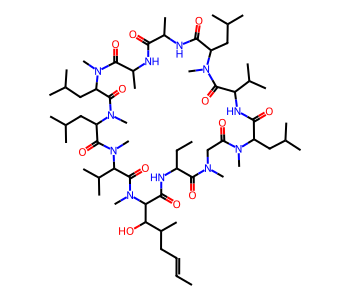

In [115]:
# 大分子默认绘图很灾难
from rdkit.Chem import rdCoordGen # 针对二维复杂体系、环状结构的优化，一旦import进来自动使用
# rdCoordGen.AddCoords(m) # 或者手动
m = Chem.MolFromSmiles("C/C=C/CC(C)C(O)C1C(=O)NC(CC)C(=O)N(C)CC(=O)N(C)C(CC(C)C)C(=O)NC(C(C)C)C(=O)N(C)C(CC(C)C)C(=O)NC(C)C(=O)NC(C)C(=O)N(C)C(CC(C)C)C(=O)N(C)C(CC(C)C)C(=O)N(C)C(C(C)C)C(=O)N1C")
m
